# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [ ]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [ ]:
# Melakukan inspeksi untuk informasi dasar dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [ ]:
# Variabel yang memiliki missing value dan jumlahnya
df.isnull().sum()[df.isnull().sum() > 0]

workclass         963
occupation        966
native-country    274
dtype: int64

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [10]:
# Jawab Soal 2.1
# workclass - Teknik mode (yang paling sering muncul)
df['workclass'] = df['workclass'].fillna(value=df['workclass'].mode()[0])

# occupation - Teknik mode (yang paling sering muncul)
df['occupation'] = df['occupation'].fillna(value=df['occupation'].mode()[0])

# native-country - Teknik mode (yang paling sering muncul)
df['native-country'] = df['native-country'].fillna(value=df['native-country'].mode()[0])

In [11]:
# Cek kembali apakah masih ada data yang hilang
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [18]:
# Jawab Soal 2
# Cek value pada fitur kualitatif
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== workclass ===
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

=== occupation ===
oc

/var/folders/2s/25gh3yb95dx460mbq4r5bfyh0000gn/T/ipykernel_62870/3324085579.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [19]:
# Melakukan penyesuaian/perbaikan
# Mengubah data ? di dataset menjadi Others
for col in categorical_columns:
    df[col] = df[col].replace('?', 'Others')

# Perbaikan kesalahan penulisan 
df['income'] = df['income'].replace('>50K.', '>50K')
df['income'] = df['income'].replace('<=50K.', '<=50K')

# Pengecekan Data Kembali
for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== workclass ===
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Others               1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

=== education ===
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

=== occupation ===
oc

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

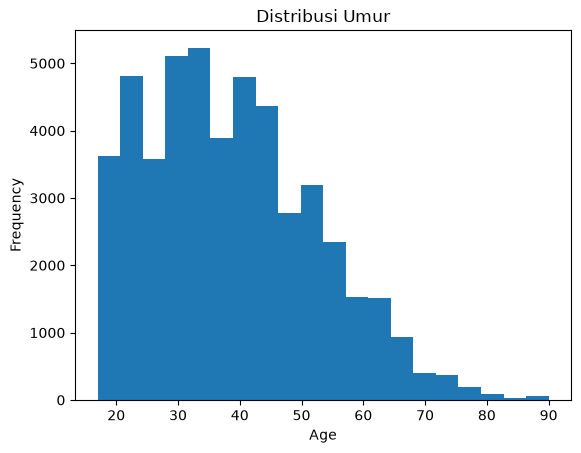

In [20]:
# Jawab 1.1 - Histrogram
import matplotlib.pyplot as plt

plt.hist(df['age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribusi Umur')
plt.show()

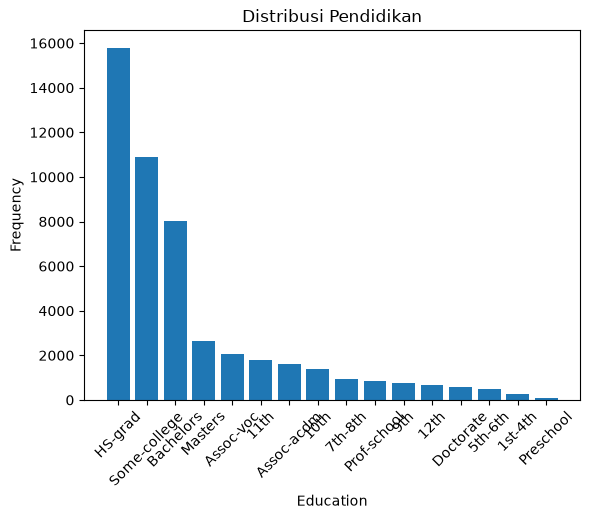

In [21]:
# Jawab 1.2 - Barchart
education_counts = df['education'].value_counts()

plt.bar(education_counts.index, education_counts.values)
plt.xlabel('Education')
plt.ylabel('Frequency')
plt.title('Distribusi Pendidikan')
plt.xticks(rotation=45)
plt.show()

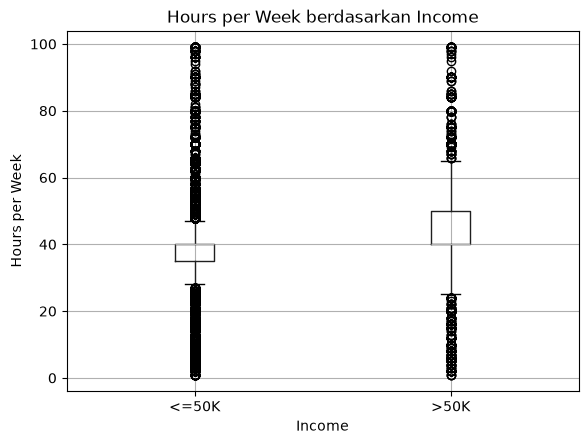

In [22]:
# Jawab 1.3 - Boxplot
df.boxplot(column='hours-per-week', by='income')

plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.title('Hours per Week berdasarkan Income')
plt.suptitle('')
plt.show()

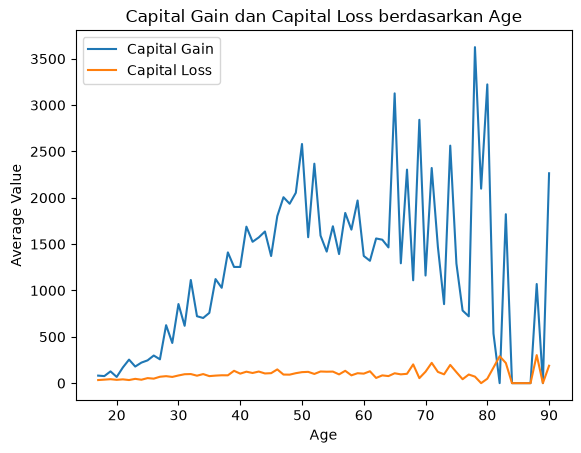

In [23]:
# Jawab 1.4 - Lineplot
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

plt.plot(age_capital.index, age_capital['capital-gain'], label='Capital Gain')
plt.plot(age_capital.index, age_capital['capital-loss'], label='Capital Loss')

plt.xlabel('Age')
plt.ylabel('Average Value')
plt.title('Capital Gain dan Capital Loss berdasarkan Age')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [24]:
# Jawab dengan komentar python

'''
1. Fenomena apa yang terjadi pada distribusi data 'age'?
Distribusi data age menunjukkan bahwa sebagian besar data berada pada rentang usia dewasa, sedangkan jumlah data pada usia yang lebih tua semakin sedikit. Distribusi tidak sepenuhnya merata.


2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
Strategi yang digunakan adalah imputasi menggunakan nilai mean dari kolom age. Mean dipilih karena age merupakan data numerik dan nilai yang hilang dapat digantikan dengan nilai rata-rata.


3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hours-per-week'? Kategori apa yang paling banyak memiliki outlier?
Jumlah outlier perlu dilihat berdasarkan hasil boxplot. Outlier dihitung menggunakan metode IQR pada hours-per-week untuk masing-masing kategori income.
'''

"\n1. Fenomena apa yang terjadi pada distribusi data 'age'?\nDistribusi data age menunjukkan bahwa sebagian besar data berada pada rentang usia dewasa, sedangkan jumlah data pada usia yang lebih tua semakin sedikit. Distribusi tidak sepenuhnya merata.\n\n\n2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?\nStrategi yang digunakan adalah imputasi menggunakan nilai mean dari kolom age. Mean dipilih karena age merupakan data numerik dan nilai yang hilang dapat digantikan dengan nilai rata-rata.\n\n\n3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hours-per-week'? Kategori apa yang paling banyak memiliki outlier?\nJumlah outlier perlu dilihat berdasarkan hasil boxplot. Outlier dihitung menggunakan metode IQR pada hours-per-week untuk masing-masing kategori income.\n"

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [25]:
# Jawab Soal 1
from sklearn.preprocessing import LabelEncoder

# Encoding Sex
sex_encoder = LabelEncoder()
df['sex'] = sex_encoder.fit_transform(df['sex'])

# Encoding Income sebagai target
income_encoder = LabelEncoder()
df['income'] = income_encoder.fit_transform(df['income'])

# Melihat hasil encoding
print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

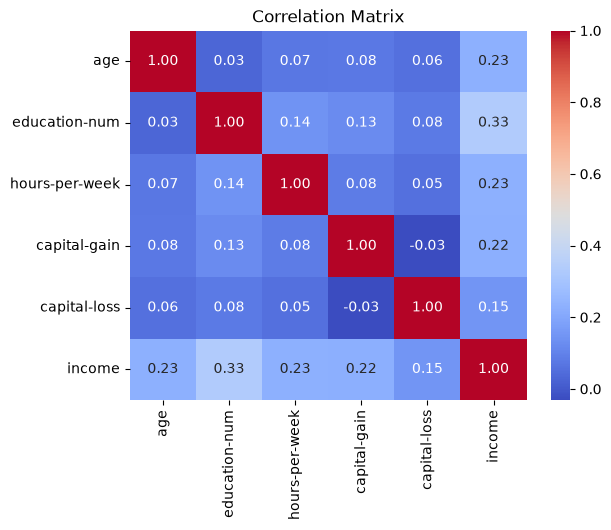

In [29]:
# Jawab Soal 1
import seaborn as sns
import matplotlib.pyplot as plt

correlation_columns = [
    'age',
    'education-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
    'income'
]

correlation_matrix = df[correlation_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()


In [30]:
# Hasil analisis jelaskan pada cell ini
'''
Hasil Analisis:

Berdasarkan correlation matrix, seluruh variabel memiliki korelasi positif terhadap income.
Education-num memiliki korelasi paling tinggi terhadap income, yaitu 0.33.
Hal ini menunjukkan bahwa semakin tinggi tingkat pendidikan, cenderung
semakin tinggi kelompok income.

Age dan hours-per-week memiliki korelasi yang sama terhadap income, yaitu 0.23.
Capital-gain memiliki korelasi sebesar 0.22, sedangkan capital-loss sebesar 0.15.

Secara keseluruhan, korelasi terhadap income tergolong lemah hingga sedang.
Education-num merupakan variabel yang memiliki hubungan paling kuat dengan
income.

Korelasi tidak menunjukkan hubungan sebab-akibat, tetapi hanya menunjukkan
adanya hubungan antar variabel.
'''

'\nHasil Analisis:\n\nBerdasarkan correlation matrix, seluruh variabel memiliki korelasi positif terhadap income.\nEducation-num memiliki korelasi paling tinggi terhadap income, yaitu 0.33.\nHal ini menunjukkan bahwa semakin tinggi tingkat pendidikan, cenderung\nsemakin tinggi kelompok income.\n\nAge dan hours-per-week memiliki korelasi yang sama terhadap income, yaitu 0.23.\nCapital-gain memiliki korelasi sebesar 0.22, sedangkan capital-loss sebesar 0.15.\n\nSecara keseluruhan, korelasi terhadap income tergolong lemah hingga sedang.\nEducation-num merupakan variabel yang memiliki hubungan paling kuat dengan\nincome.\n\nKorelasi tidak menunjukkan hubungan sebab-akibat, tetapi hanya menunjukkan\nadanya hubungan antar variabel.\n'

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [2]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


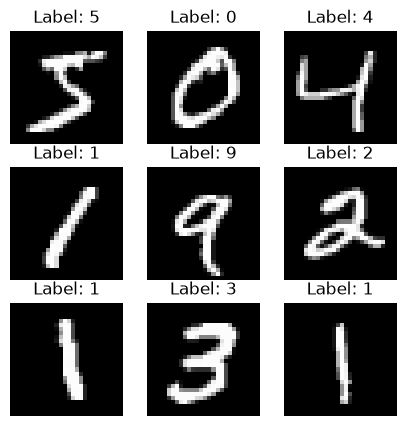

In [3]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [6]:
# Jawab Soal 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membuat array kosong untuk menampung hasil upsampling
X_test_upsampled = np.empty((10000, 32, 32), dtype=X_test.dtype)

# Upsampling seluruh data X_test dari 28x28 menjadi 32x32
for i in range(len(X_test)):
    X_test_upsampled[i] = cv2.resize(
        X_test[i],
        (32, 32),
        interpolation=cv2.INTER_LINEAR
    )

print("Shape sebelum upsampling:", X_test.shape)
print("Shape setelah upsampling:", X_test_upsampled.shape)

Shape sebelum upsampling: (10000, 28, 28)
Shape setelah upsampling: (10000, 32, 32)


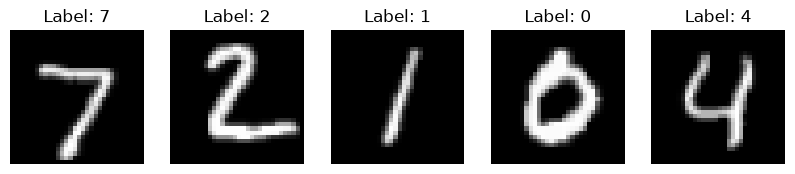

In [7]:
# Tampilan 5 Hasil upsampling
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')

plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [8]:
# Jawab Soal 2
# Normalisasi nilai piksel dari 0-255 menjadi 0-1
X_test_normalized = X_test_upsampled.astype('float32') / 255.0

print("Nilai minimum:", X_test_normalized.min())
print("Nilai maksimum:", X_test_normalized.max())

Nilai minimum: 0.0
Nilai maksimum: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [9]:
# Jawab Soal 3

# Membuat holder array kosong
X_test_flattened = np.empty(
    (len(X_test_normalized), 32 * 32),
    dtype=X_test_normalized.dtype
)

# Mengubah semua citra menjadi array 1 dimensi
for i in range(len(X_test_normalized)):
    X_test_flattened[i] = X_test_normalized[i].flatten()

# Menampilkan hasil
print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape setelah flatten:", X_test_flattened.shape)

print("\n5 data pertama setelah flatten:")
print(X_test_flattened[:5])

Shape sebelum flatten: (10000, 32, 32)
Shape setelah flatten: (10000, 1024)

5 data pertama setelah flatten:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
